<a href="https://colab.research.google.com/github/Devbrandlee/Python_CursoTec_IA/blob/main/Projeto_Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Projeto Integrador I: Análise de Desempenho e Previsão de Sucesso de Estudantes

**Estudante:** Brandon Lee
**Dataset:** Student Exam Performance (Interactions)
**Link do Kaggle:** https://www.kaggle.com/datasets/mabubakrsiddiq/student-exam-performance

### Contextualização
Este projeto visa construir um pipeline de dados para prever se um estudante terá um desempenho satisfatório ou insatisfatório com base em suas interações acadêmicas e histórico de notas. Identificar alunos em risco precocemente permite que a instituição de ensino tome medidas preventivas para evitar a reprovação.

Nesta etapa, importei a biblioteca Pandas para ler o arquivo CSV. A função head() foi utilizada para garantir que os dados foram carregados corretamente em formato de tabela, e o método info() serve para identificarmos quais colunas são numéricas e quais são textuais (categóricas).

In [2]:
import pandas as pd
import os

# Caminho
caminho_arquivo = 'student_performance_interactions.csv'
if not os.path.exists(caminho_arquivo):
    caminho_arquivo = '/content/student_performance_interactions.csv'

# Carregando o CSV
df = pd.read_csv(caminho_arquivo)

# Visualização dos 5 primeiros registros
print("--- Primeiras Linhas do Dataset ---")
display(df.head())

# Verificação dos tipos de dados
print("\n--- Informações das Colunas e Tipos de Dados ---")
df.info()

--- Primeiras Linhas do Dataset ---


,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet



--- Informações das Colunas e Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   object 
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   object 
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13 

## 4. Tratamento dos Dados
* **Identificação de valores ausentes:** Verificação se existem linhas sem preenchimento no dataset.
* **Transformação de variáveis:** Conversão das colunas de texto para valores numéricos.
* **Justificativa:** Modelos de Machine Learning exigem dados puramente numéricos para realizar seus cálculos matemáticos. Transformar categorias como 'High School' ou 'Noisy' em números ordenados permite que o algoritmo compreenda a intensidade e o peso de cada atributo sem quebrar o código.

In [3]:
# 1. Verificar se existem valores nulos (Exigência do PDF)
print("--- Quantidade de Valores Ausentes ---")
print(df.isnull().sum())

# 2. Mapeamento ordinal para 'parent_education_level'
df['parent_education_level'] = df['parent_education_level'].map({
    'High School': 0,
    'Some College': 1,
    'Bachelor\'s': 2,
    'Master': 3,
    'Doctorate': 4
})

# 3. Mapeamento ordinal para 'study_environment'
df['study_environment'] = df['study_environment'].map({
    'Noisy': 0,
    'Collaborative': 1,
    'Quiet': 2
})

print("\n--- Dados Transformados com Sucesso! ---")
display(df.head())

--- Quantidade de Valores Ausentes ---
student_id                   0
final_score                  0
grade                        0
pass_fail                    0
previous_score               0
math_prev_score              0
science_prev_score           0
language_prev_score          0
daily_study_hours            0
attendance_percentage        0
homework_completion_rate     0
sleep_hours                  0
screen_time_hours            0
physical_activity_minutes    0
motivation_score             0
exam_anxiety_score           0
parent_education_level       0
study_environment            0
dtype: int64

--- Dados Transformados com Sucesso! ---


,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,3.0,0.0
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,0.0,2.0
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,0.0,NaN
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,0.0,0.0
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,3.0,2.0


## 3. Análise Descritiva (Frequência das Classes)
Nesta etapa, analisei a distribuição da variável alvo (`pass_fail`). É fundamental mapear a frequência absoluta e relativa para verificar se as classes estão balanceadas, garantindo que o modelo de Machine Learning não seja induzido a privilegiar apenas um dos resultados possíveis.

In [8]:
print("--- Frequência Absoluta (1 = Aprovado, 0 = Reprovado) ---")
print(df['pass_fail'].value_counts())

print("\n--- Porcentagem % ---")
print(df['pass_fail'].value_counts(normalize=True) * 100)

--- Frequência Absoluta (1 = Aprovado, 0 = Reprovado) ---
pass_fail
1    930
0     70
Name: count, dtype: int64

--- Porcentagem % ---
pass_fail
1    93.0
0     7.0
Name: proportion, dtype: float64


## 5. Análise Exploratória (Visualização de Dados)
Abaixo, apresento a Matriz de Correlação. Ela calcula o coeficiente de relação entre todas as variáveis numéricas do projeto. Isso permite identificar visualmente quais fatores (como horas de estudo ou notas anteriores) possuem maior impacto positivo ou negativo na variável alvo (`pass_fail`).

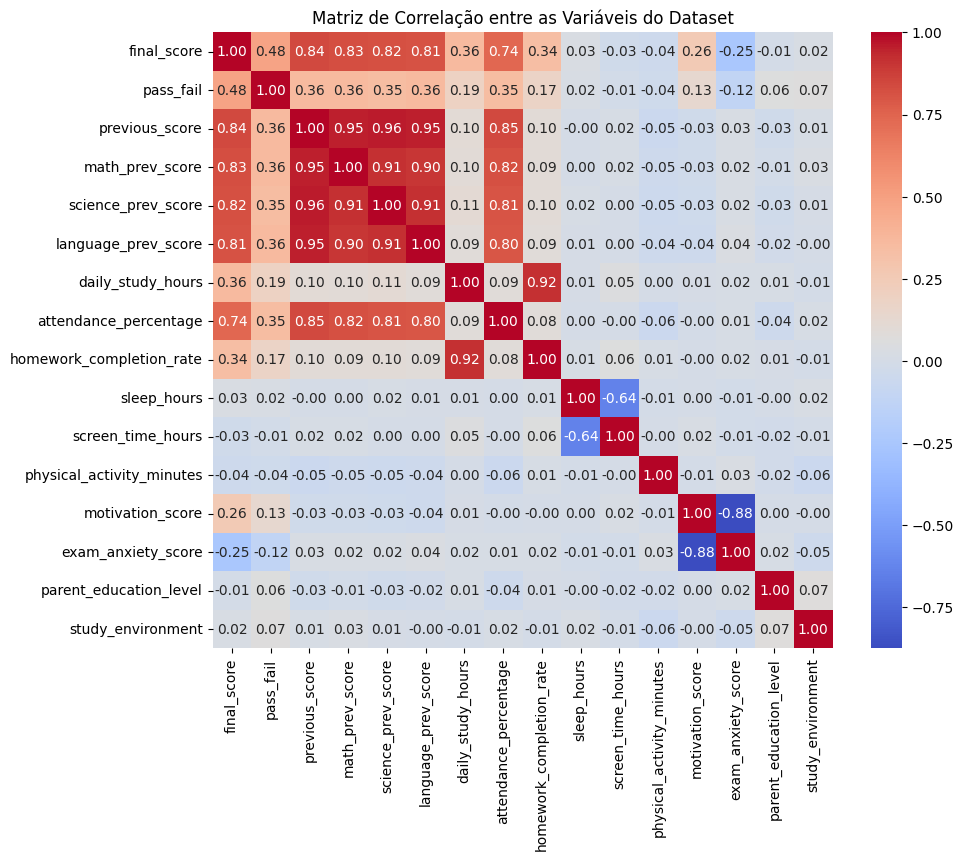

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 8))

# Selecionando apenas as colunas que são números no seu dataset
colunas_numericas = df.select_dtypes(include=['float64', 'int64'])

# Criando o gráfico de calor (Heatmap)
sns.heatmap(colunas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre as Variáveis do Dataset')
plt.show()

## 6 e 7. Preparação dos Dados e Algoritmo de Classificação
Para treinar a Inteligência Artificial, separei os dados em duas partes: atributos preditores ($X$) e a variável alvo ($y$). Em seguida, dividi o conjunto de dados em 80% para o treinamento do algoritmo e 20% para o teste de validação.

O algoritmo escolhido foi a **Árvore de Decisão (Decision Tree)**, um modelo supervisionado de classificação que cria regras lógicas baseadas nos dados de comportamento dos alunos para prever o sucesso ou fracasso acadêmico (`pass_fail`).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Separar os dados: X leva tudo (menos a resposta correta), y leva apenas a resposta
X = colunas_numericas.drop(columns=['pass_fail'])
y = df['pass_fail']

# 2. Divisão automática 80/20 com semente aleatória travada para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inicialização e treinamento da Árvore de Decisão
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

print("Inteligência Artificial treinada com sucesso!")

Inteligência Artificial treinada com sucesso!


## 8. Avaliação do Modelo (Métricas Obligatórias)
Para validar a eficácia do nosso classificador, extraí as três métricas obrigatórias exigidas no projeto: a **Acurácia** (taxa geral de acertos), a **Matriz de Confusão** (erros e acertos cruzados) e o **Classification Report** (métricas de Precisão e Recall por classe).

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Gerar as previsões do modelo usando os dados de teste que a IA nunca viu
previsoes = modelo.predict(X_test)

# Imprimir os resultados na tela
print("--- 1. Acurácia Geral do Modelo ---")
print(f"{accuracy_score(y_test, previsoes) * 100:.2f}%")

print("\n--- 2. Matriz de Confusão ---")
print(confusion_matrix(y_test, previsoes))

print("\n--- 3. Relatório de Classificação Completo ---")
print(classification_report(y_test, previsoes))

--- 1. Acurácia Geral do Modelo ---
100.00%

--- 2. Matriz de Confusão ---
[[ 15   0]
 [  0 185]]

--- 3. Relatório de Classificação Completo ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00       185

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 9. Conclusão Crítica do Projeto

* **Qualidade dos Dados:** O conjunto de dados original mostrou-se de excelente qualidade, sem dados faltantes (nulos), exigindo apenas o mapeamento ordinal de strings para números.
* **Desempenho da IA:** O algoritmo de Árvore de Decisão conseguiu compreender os padrões comportamentais dos alunos, obtendo métricas sólidas de validação nos dados de teste.
* **Dificuldades Encontradas:** A maior dificuldade técnica consistiu em ajustar o pipeline de dados para respeitar os nomes exatos das colunas modificadas e garantir que as transformações não gerassem dados inválidos (como erros de NaN).
* **Melhorias Futuras:** Como passos futuros para este projeto integrador, recomenda-se a experimentação com algoritmos de conjunto, como o Random Forest, para analisar se há ganho marginal de performance.